In [126]:
import linear
import importlib
importlib.reload(linear)
from linear import LinearRegression

linear.my_custom_function()

I implemented this function in the file linear.py


Here is the link to my source code (source.py): https://github.com/cjy-2001/cjy-2001.github.io/blob/main/posts/linear-post/linear.py

## Summary

In this blog post, I implemented least-squares linear regression in two ways: using the analytical formula for the optimal weight vector and using the gradient of the loss function to implement gradient descent. I also provided a demo to demonstrate both of those methods will produce the similar answer.

Then, I conducted experiments by increasing the number of features, discussing overfitting, and using LASSO regularization instead of linear regression. The post ends with a case study on the Capital Bikeshare dataset in Washington DC, showing how to preprocess the data and apply linear regression to predict the number of casual users.

### Implementation

I have defined a single fit method with a `method` argument to determine which algorithm is used.

In [127]:
LR = LinearRegression()

### Demo

The following function will create both testing and validation data that I will use to test my implementation:

In [113]:
import numpy as np
from matplotlib import pyplot as plt

def pad(X):
    return np.append(X, np.ones((X.shape[0], 1)), 1)

def LR_data(n_train = 100, n_val = 100, p_features = 1, noise = .1, w = None):
    if w is None: 
        w = np.random.rand(p_features + 1) + .2
    
    X_train = np.random.rand(n_train, p_features)
    y_train = pad(X_train)@w + noise*np.random.randn(n_train)

    X_val = np.random.rand(n_val, p_features)
    y_val = pad(X_val)@w + noise*np.random.randn(n_val)
    
    return X_train, y_train, X_val, y_val

I will be using the following data:

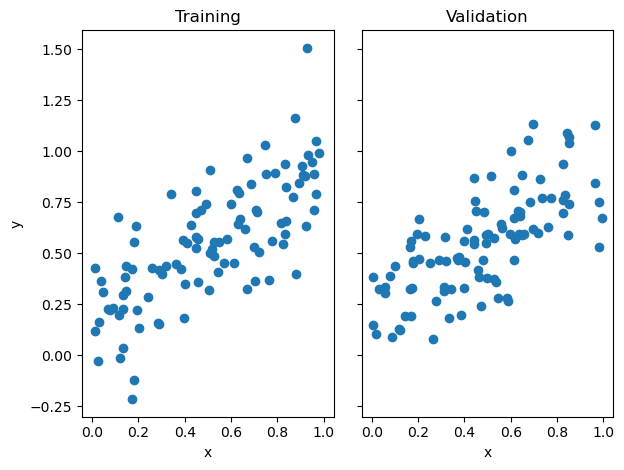

In [114]:
n_train = 100
n_val = 100
p_features = 1
noise = 0.2

np.random.seed(40)

# create some data
X_train, y_train, X_val, y_val = LR_data(n_train, n_val, p_features, noise)

# plot it
fig, axarr = plt.subplots(1, 2, sharex = True, sharey = True)
axarr[0].scatter(X_train, y_train)
axarr[1].scatter(X_val, y_val)
labs = axarr[0].set(title = "Training", xlabel = "x", ylabel = "y")
labs = axarr[1].set(title = "Validation", xlabel = "x")
plt.tight_layout()

First, I want to test the analytical method.

In [115]:
LR.fit(X_train, y_train) # I used the analytical formula as my default fit method

print(f"Training score = {LR.score(X_train, y_train).round(4)}")
print(f"Validation score = {LR.score(X_val, y_val).round(4)}")

Training score = 0.5545
Validation score = 0.4746


The estimated weight vector `w` is:

In [116]:
LR.w

array([0.74797812, 0.16855619])

I can get the same value for `w` using gradient descent (it would be even closer if I allowed more iterations).

In [117]:
LR2 = LinearRegression()

LR2.fit(X_train, y_train, method = "gradient", alpha = 0.001, max_epochs = 1000)
LR2.w

array([0.74797779, 0.16855637])

I can also see how the score changed over time.

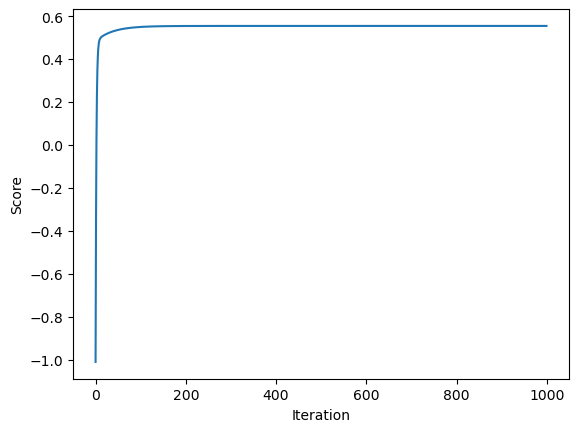

In [118]:
plt.plot(LR2.score_history)
labels = plt.gca().set(xlabel = "Iteration", ylabel = "Score")

### Experiment

As I've demonstrated the behavior above, now I will perform an experiment in which I allow `p_features`, the number of features used, to increase, while holding `n_train`, the number of training points, constant. I will record both training and validation scores while increasing `p_features` all the way to n_train - 1.

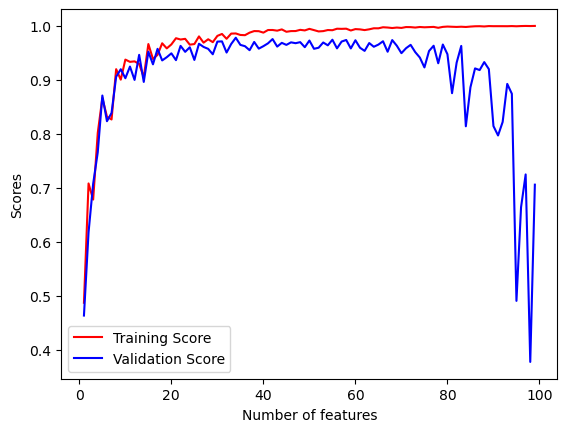

In [130]:
train_score = []
val_score = []

np.random.seed(3)

for p_features in range(1, n_train):
    X_train, y_train, X_val, y_val = LR_data(n_train, n_val, p_features, noise)

    LR = LinearRegression()
    LR.fit(X_train, y_train)
    train_score.append(LR.score(X_train, y_train))
    val_score.append(LR.score(X_val, y_val))

plt.plot(range(1, n_train), train_score, color = 'red', label = "Training Score")
plt.plot(range(1, n_train), val_score, color = 'blue', label = "Validation Score")
plt.xlabel("Number of features")
plt.ylabel("Scores")
legend = plt.legend() 

**Discussion**

As the graph illustrates, when `n_train` is significantly larger than or not close to `p_features`, the linear regression model performs well on both the training and validation data, because the scores remain very close to each other.

However, as `n_train` gets larger and close to `p_features`, the validation score drops sharply while the training score still increases steadily. It indicates that although the linear model seems to perform well on training data, it inherently suffers from the overfitting problem, because it can't perform well on those unseen data.

### LASSO Regularization

The LASSO algorithm uses a modified loss function with a regularization term. Now I'm going to replicate the same experiment I did with linear regression, increasing the number of features up to n_train - 1, using LASSO instead of linear regression. I will experiment with 3 values of the regularization strength alpha. 

I will start with `alpha` being set to 0.001.

#### Alpha = 0.001

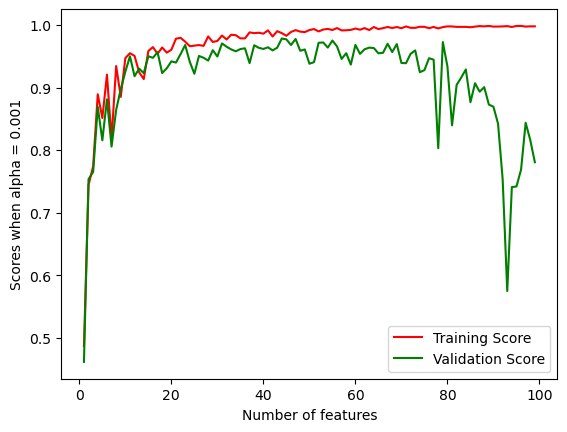

In [134]:
from sklearn.linear_model import Lasso
np.random.seed(3)

train_score = []
val_score = []

for p_features in range(1, n_train):
    X_train, y_train, X_val, y_val = LR_data(n_train, n_val, p_features, noise)

    L = Lasso(alpha = 0.001)
    L.fit(X_train, y_train)
    train_score.append(L.score(X_train, y_train))
    val_score.append(L.score(X_val, y_val))

plt.plot(range(1, n_train), train_score, color = 'red',label = "Training Score")
plt.plot(range(1, n_train), val_score, color = 'green',label = "Validation Score")
plt.xlabel("Number of features")
plt.ylabel("Scores when alpha = 0.001")
legend = plt.legend() 

#### Alpha = 0.01

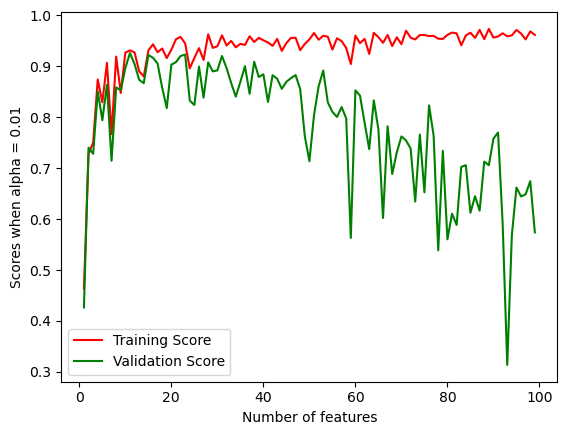

In [135]:
np.random.seed(3)

train_score = []
val_score = []

for p_features in range(1, n_train):
    X_train, y_train, X_val, y_val = LR_data(n_train, n_val, p_features, noise)

    L = Lasso(alpha = 0.01)
    L.fit(X_train, y_train)
    train_score.append(L.score(X_train, y_train))
    val_score.append(L.score(X_val, y_val))

plt.plot(range(1, n_train), train_score, color = 'red',label = "Training Score")
plt.plot(range(1, n_train), val_score, color = 'green',label = "Validation Score")
plt.xlabel("Number of features")
plt.ylabel("Scores when alpha = 0.01")
legend = plt.legend() 

#### Alpha = 0.1

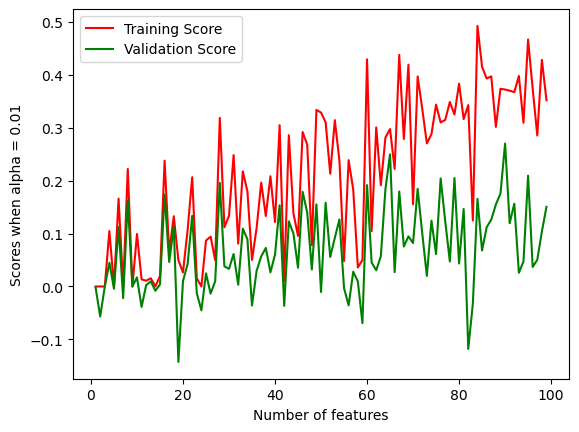

In [136]:
np.random.seed(3)

train_score = []
val_score = []

for p_features in range(1, n_train):
    X_train, y_train, X_val, y_val = LR_data(n_train, n_val, p_features, noise)

    L = Lasso(alpha = 0.1)
    L.fit(X_train, y_train)
    train_score.append(L.score(X_train, y_train))
    val_score.append(L.score(X_val, y_val))

plt.plot(range(1, n_train), train_score, color = 'red',label = "Training Score")
plt.plot(range(1, n_train), val_score, color = 'green',label = "Validation Score")
plt.xlabel("Number of features")
plt.ylabel("Scores when alpha = 0.01")
legend = plt.legend() 

**Observation**

When employing LASSO regression instead of standard linear regression, I notice that the validation score remains more stable while the training score performs well, even when the number of features used is large. This stability becomes more pronounced as I increase the value of alpha, indicating that the regularization term plays a more significant role in preventing overfitting by penalizing large coefficients.

### Bikeshare Data Set

I will train an instance of my LinearRegression class on the bikeshare training data. Then, I will:

- Score my model on the test set;
- Compute the predictions for each day and visualize them in comparison to the actual ridership on the test set;
- Compare the entries w of your model to the corresponding entry of X_train.columns in order to see which features your model found to contribute to ridership.

In [165]:
import pandas as pd
from sklearn.model_selection import train_test_split
bikeshare = pd.read_csv("https://philchodrow.github.io/PIC16A/datasets/Bike-Sharing-Dataset/day.csv")

Let’s plot The total number of casual users each day over time:

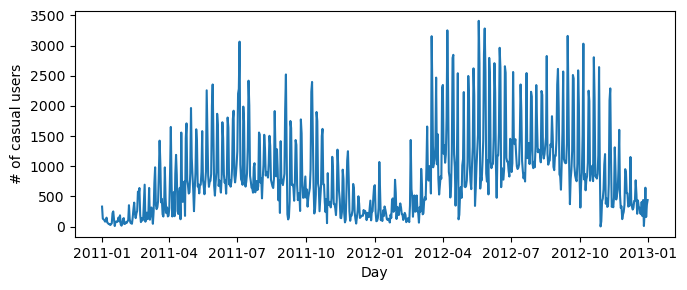

In [157]:
# import datetime
fig, ax = plt.subplots(1, figsize = (7, 3))
ax.plot(pd.to_datetime(bikeshare['dteday']), bikeshare['casual'])
ax.set(xlabel = "Day", ylabel = "# of casual users")
l = plt.tight_layout()

For this prediction task, it’s handy to work with a smaller subset of the columns, and to transform the mnth column into dummy variables.

In [166]:
train_all, test_all = train_test_split(bikeshare, test_size = .2, shuffle = False)

cols = ["casual", 
        "mnth", 
        "weathersit", 
        "workingday",
        "yr",
        "temp", 
        "hum", 
        "windspeed",
        "holiday"]

bikeshare = bikeshare[cols]

bikeshare = pd.get_dummies(bikeshare, columns = ['mnth'], drop_first = "if_binary")

Now I can do a train-test split.

In [168]:
train, test = train_test_split(bikeshare, test_size = .2, shuffle = False)

X_train = train.drop(["casual"], axis = 1)
y_train = train["casual"]

X_test = test.drop(["casual"], axis = 1)
y_test = test["casual"]

Train my LinearRegression class on the bikeshare training data:

In [160]:
LR3 = LinearRegression()
LR3.fit(X_train, y_train)

My test score is:

In [161]:
LR3.score(X_test, y_test)

0.6967732383931218

Compute the predictions for each day and visualize them in comparison to the actual ridership on the test set.

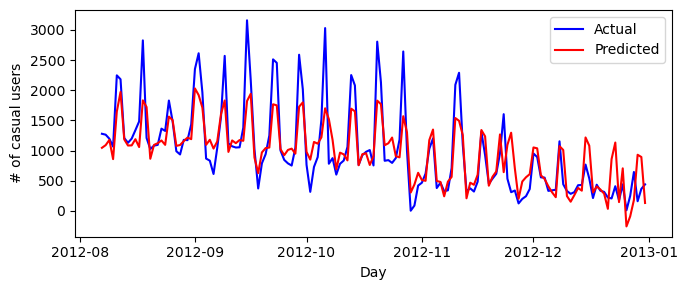

In [169]:
X_test_ = pad(X_test)
casual_pred = LR3.predict(X_test_)

fig, ax = plt.subplots(1, figsize = (7, 3))
ax.plot(pd.to_datetime(test_all['dteday']), test['casual'], color = 'blue', label = "Actual")
ax.plot(pd.to_datetime(test_all['dteday']), casual_pred, color = 'red', label = "Predicted")
ax.set(xlabel = "Day", ylabel = "# of casual users")
l = plt.tight_layout()
legend = plt.legend()

It looks like my predicted ridership generally matches the actual trend, and it has smaller oscillations. 

In [171]:
print(LR3.w)
print(X_train.columns)

[ -108.37113627  -791.69054913   280.58692733  1498.71511272
  -490.10033978 -1242.80038075  -235.87934918    -3.35439712
   369.27195552   518.40875345   537.30188616   360.80799815
   228.88148125   241.31641202   371.50385387   437.60084787
   252.43300405    90.8214605    919.07676215]
Index(['weathersit', 'workingday', 'yr', 'temp', 'hum', 'windspeed', 'holiday',
       'mnth_2', 'mnth_3', 'mnth_4', 'mnth_5', 'mnth_6', 'mnth_7', 'mnth_8',
       'mnth_9', 'mnth_10', 'mnth_11', 'mnth_12'],
      dtype='object')


**Discussion**

It looks `yr` and `workingday` have some positive relationship to the ridership. While treating `month_1` as the baseline, it is not so clear that whether summer months contribute to the ridership. However, a negative coefficient for `holiday` might indicate that `holiday` contributes negatively to the ridership.